# Hyperedge curvature: within vs between clusters

Assignment rules (all three agree on cardinality-2 edges):

| mode | the edge gets a cluster when | so it is 'between clusters' when |
| --- | --- | --- |
| `strict` | **every** node sits in one cluster | it touches 2 or more clusters |
| `majority` | **more than half** the nodes sit in one cluster | no cluster holds a strict majority |

## 1. Configuration

In [ ]:
from pathlib import Path

# --- inputs -----------------------------------------------------------------
ROOT = Path()

CURVATURE_PATH = ROOT / 'results/synthetic_data/cluster_id1/hyperedge/OR_MMOT_curvature.txt'
CLUSTERS_PATH  = ROOT / 'data/synthetic_data/true_clusters/cluster_id1.txt'

# --- classification ---------------------------------------------------------
ASSIGNMENT_MODE = 'strict'         # 'strict' | 'majority' 

# What 'between clusters' means:
#   'unassigned' -> ASSIGNMENT_MODE failed to give the edge a single cluster
#   'impure'     -> the edge touches more than one cluster (mode independent)
BETWEEN_DEFINITION = 'unassigned'

# --- plot -------------------------------------------------------------------
HIST_BINS = 25        # only used when the curvature is not integer valued
DENSITY = False       # True normalises each group, useful when the two differ a lot in size
SAVE_PATH = None      # e.g. ROOT / 'figures/curvature_within_between.png'

In [11]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colour-blind-safe pair; the hatching keeps the split alive in greyscale.
C_WITHIN, C_BETWEEN = '#0072B2', '#D55E00'

## 2. Loading

In [12]:
def _coerce(token):
    """Cluster labels become ints where possible, otherwise stay strings."""
    try:
        return int(token)
    except ValueError:
        return token


def load_curvature_file(path):
    """Parse `n1,n2,n3 : curvature` lines; the ROW NUMBER is the hyperedge id.

    An explicit leading id column (`edge_id <tab> n1,n2,... : curvature`) is also
    accepted. Returns {edge_id: (nodes,)} and {edge_id: float}.
    """
    edges, curvature, skipped = {}, {}, 0

    for row, raw in enumerate(Path(path).read_text().splitlines(), start=1):
        line = raw.strip()
        if not line:
            skipped += 1
            continue

        left, sep, right = line.rpartition(':')
        if not sep:                        # no ':' on the line
            left, right = line, ''

        fields = left.split()
        if not fields:
            skipped += 1
            continue

        # The node list is the field holding commas; anything before it is an
        # explicit edge id, otherwise the row number is the edge id.
        node_idx = next((i for i, f in enumerate(fields) if ',' in f), len(fields) - 1)
        eid = row
        if node_idx > 0:
            try:
                eid = int(fields[0])
            except ValueError:
                eid = row

        try:
            nodes = tuple(sorted({int(x) for x in fields[node_idx].split(',') if x.strip()}))
        except ValueError:
            skipped += 1
            continue
        if not nodes:
            skipped += 1
            continue

        edges[eid] = nodes
        try:
            curvature[eid] = float(right.strip())
        except ValueError:
            curvature[eid] = float('nan')

    if skipped:
        print('  note: skipped', skipped, 'blank/unparseable line(s) in', Path(path).name)
    return edges, curvature


def load_clusters(path):
    """One cluster label per line, the ROW NUMBER being the node id.

    A two-column `node_id <tab> cluster_id` file is also accepted.
    """
    mapping = {}
    for row, raw in enumerate(Path(path).read_text().splitlines(), start=1):
        fields = raw.split()
        if not fields:
            continue
        if len(fields) >= 2:
            mapping[int(fields[0])] = _coerce(fields[1])
        else:
            mapping[row] = _coerce(fields[0])
    return mapping


edges, curvature = load_curvature_file(CURVATURE_PATH)
node_cluster = load_clusters(CLUSTERS_PATH)

if not edges:
    raise ValueError('No hyperedges parsed from ' + str(CURVATURE_PATH))

print('hyperedges       :', len(edges))
print('curvature values :', sum(not np.isnan(v) for v in curvature.values()), '/', len(edges))
print('nodes w/ cluster :', len(node_cluster),
      '-> clusters', sorted(set(node_cluster.values()), key=str))

missing = {n for ns in edges.values() for n in ns} - set(node_cluster)
if missing:
    print('warning:', len(missing), 'node(s) in edges have no cluster label,',
          'e.g.', sorted(missing)[:10])

hyperedges       : 2213
curvature values : 2213 / 2213
nodes w/ cluster : 1000 -> clusters [1, 2, 3]


## 3. Within or between clusters

In [13]:
def classify(nodes, node_cluster, mode=ASSIGNMENT_MODE, between=BETWEEN_DEFINITION):
    """Return (assigned cluster or None, is_between) for one hyperedge."""
    labels = [node_cluster[n] for n in nodes if n in node_cluster]
    if not labels:
        return None, True

    counts = Counter(labels)
    n = len(labels)
    top, top_count = counts.most_common(1)[0]

    if mode == 'strict':
        assigned = top if len(counts) == 1 else None
    elif mode == 'majority':
        assigned = top if 2 * top_count > n else None
    elif mode == 'linear':
        tied = sum(1 for k in counts.values() if k == top_count)
        assigned = top if tied == 1 else None
    else:
        raise ValueError('unknown mode ' + repr(mode) + '; expected strict / majority / linear')

    if between == 'unassigned':
        is_between = assigned is None
    elif between == 'impure':
        is_between = len(counts) > 1
    else:
        raise ValueError("BETWEEN_DEFINITION must be 'unassigned' or 'impure'")

    return assigned, is_between


rows = []
for eid, nodes in edges.items():
    cluster, is_between = classify(nodes, node_cluster)
    rows.append({
        'edge_id': eid,
        'nodes': nodes,
        'cardinality': len(nodes),
        'curvature': curvature.get(eid, float('nan')),
        'cluster': cluster,
        'is_between': is_between,
    })

df = pd.DataFrame(rows).sort_values('edge_id').reset_index(drop=True)
df['membership'] = np.where(df['is_between'], 'between clusters', 'within cluster')

print('mode =', repr(ASSIGNMENT_MODE), '  between =', repr(BETWEEN_DEFINITION))
print(df.groupby('membership')['curvature']
        .agg(n='size', mean='mean', median='median', std='std').round(3))

mode = 'strict'   between = 'unassigned'
                     n   mean  median    std
membership                                  
between clusters   363 -0.966  -0.940  0.203
within cluster    1850 -0.766  -0.761  0.203


## 4. Histogram of curvatures

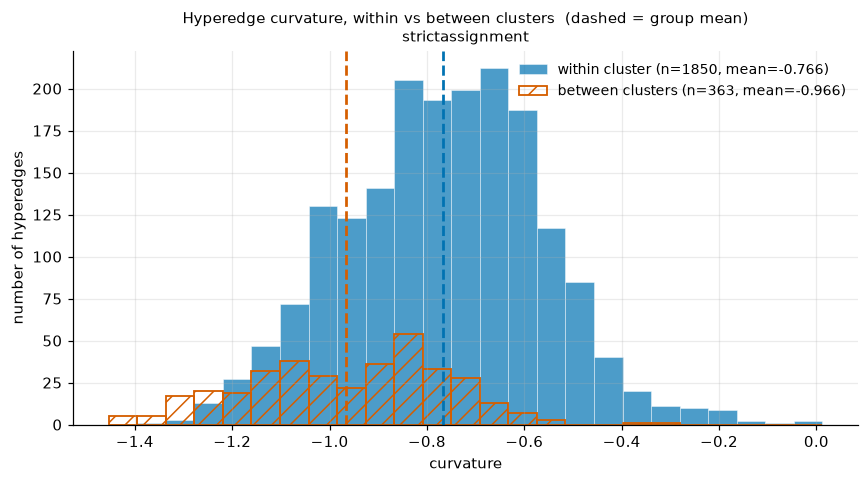

In [14]:
def _bin_edges(values, bins=HIST_BINS):
    """Integer-aligned bins when the curvature is integer valued, else regular bins."""
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.linspace(0.0, 1.0, 2)
    if np.allclose(v, np.round(v)) and (v.max() - v.min()) <= 60:
        return np.arange(v.min() - 0.5, v.max() + 1.5, 1.0)
    return np.histogram_bin_edges(v, bins=bins)


vw = df.loc[~df['is_between'], 'curvature'].dropna().to_numpy()
vb = df.loc[df['is_between'], 'curvature'].dropna().to_numpy()
bin_edges = _bin_edges(np.concatenate([vw, vb]) if len(vw) + len(vb) else [0.0])

fig, ax = plt.subplots(figsize=(8, 4.5))

if len(vw):
    ax.hist(vw, bins=bin_edges, density=DENSITY, color=C_WITHIN, alpha=0.70,
            edgecolor='white', linewidth=0.4,
            label='within cluster (n=' + str(len(vw)) + ', mean=' + format(vw.mean(), '.3g') + ')')
    ax.axvline(vw.mean(), color=C_WITHIN, linestyle='--', linewidth=1.8)

if len(vb):
    ax.hist(vb, bins=bin_edges, density=DENSITY, facecolor='none', edgecolor=C_BETWEEN,
            hatch='//', linewidth=1.2,
            label='between clusters (n=' + str(len(vb)) + ', mean=' + format(vb.mean(), '.3g') + ')')
    ax.axvline(vb.mean(), color=C_BETWEEN, linestyle='--', linewidth=1.8)

ax.set_xlabel('curvature')
ax.set_ylabel('density' if DENSITY else 'number of hyperedges')
ax.set_title('Hyperedge curvature, within vs between clusters  (dashed = group mean)\n' + ASSIGNMENT_MODE + 'assignment', fontsize=10)
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()

if SAVE_PATH is not None:
    Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_PATH, bbox_inches='tight', dpi=150)

plt.show()

In [15]:
from scipy.stats import mannwhitneyu

# H0: between-cluster curvature >= within-cluster curvature
# H1: between-cluster curvature <  within-cluster curvature
res = mannwhitneyu(vw, vb, alternative='greater')

print('Mann-Whitney U (one-sided, within > between)')
print('  n within / between :', len(vw), '/', len(vb))
print('  median within      :', round(float(np.median(vw)), 4))
print('  median between     :', round(float(np.median(vb)), 4))
print('  U                  :', res.statistic)
print('  p-value            :', format(res.pvalue, '.3e'))

Mann-Whitney U (one-sided, within > between)
  n within / between : 1850 / 363
  median within      : -0.7607
  median between     : -0.94
  U                  : 504885.5
  p-value            : 1.980e-52
